In [17]:
%pip install pandas scikit-learn matplotlib seaborn

  Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━

In [38]:
# --- IMPORTACIONES ---
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from torch.utils.data import TensorDataset, DataLoader

# --- REPRODUCIBILIDAD (Requisito de la rúbrica) ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# --- DEVICE MANAGEMENT ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de entrenamiento: {device}")

Dispositivo de entrenamiento: cpu


In [8]:
import pandas as pd

# Subimos un nivel (..) y entramos en la carpeta data
df = pd.read_csv('../data/insurance.csv')

# Ver información básica
print("--- INFO DEL DATASET ---")
print(df.info())

# Ver si hay valores nulos
print("\n--- VALORES NULOS ---")
print(df.isnull().sum())

# Estadísticas básicas
print("\n--- ESTADÍSTICAS BÁSICAS ---")
display(df.describe())

--- INFO DEL DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None

--- VALORES NULOS ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- ESTADÍSTICAS BÁSICAS ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


/tmp/ipykernel_636/1129683812.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', ax=axes[0], palette='Set2')


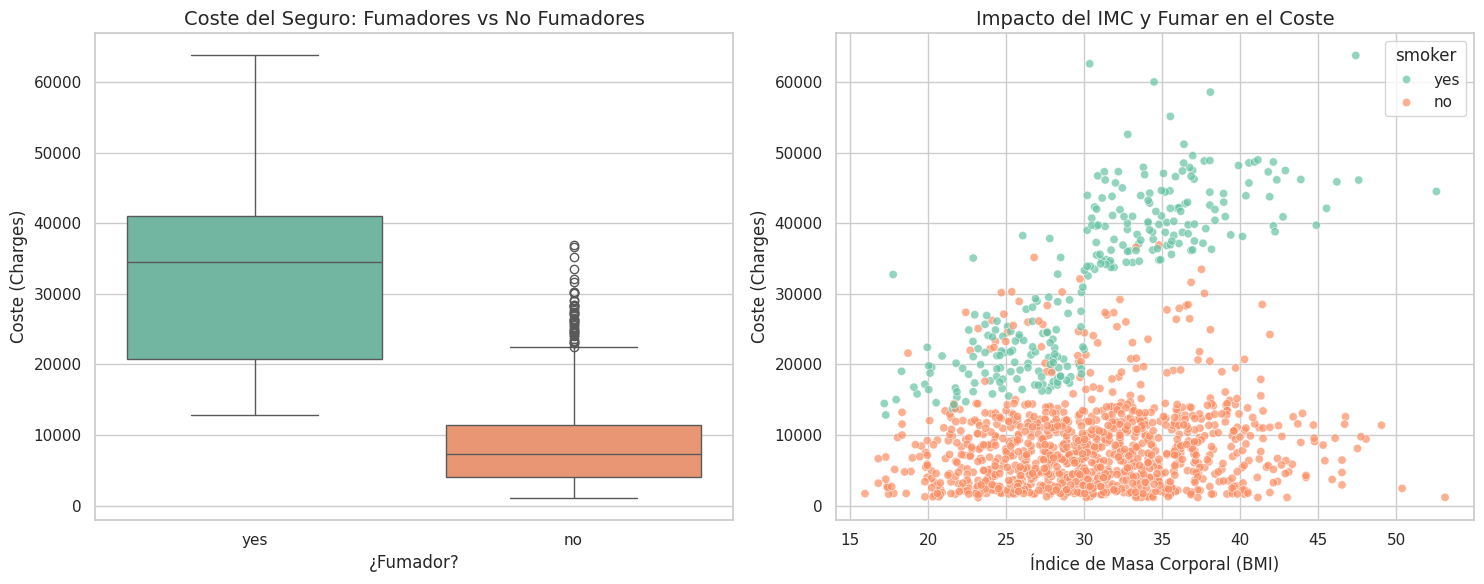

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Crear una figura con dos gráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: ¿Cómo afecta fumar al precio?
sns.boxplot(data=df, x='smoker', y='charges', ax=axes[0], palette='Set2')
axes[0].set_title('Coste del Seguro: Fumadores vs No Fumadores', fontsize=14)
axes[0].set_xlabel('¿Fumador?')
axes[0].set_ylabel('Coste (Charges)')

# Gráfico 2: Relación entre IMC (bmi), Coste y si fuma
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', ax=axes[1], palette='Set2', alpha=0.7)
axes[1].set_title('Impacto del IMC y Fumar en el Coste', fontsize=14)
axes[1].set_xlabel('Índice de Masa Corporal (BMI)')
axes[1].set_ylabel('Coste (Charges)')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# ---------------------------------------------------------
# 1. ONE-HOT ENCODING (Texto a Números)
# ---------------------------------------------------------
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# ---------------------------------------------------------
# 2. SEPARAR X (Características) e y (Objetivo)
# ---------------------------------------------------------
X = df_encoded.drop('charges', axis=1) # Todo menos el precio
y = df_encoded['charges']              # Solo el precio

# ---------------------------------------------------------
# 3. DIVIDIR LOS DATOS ESTRATIFICANDO POR FUMADORES
# ---------------------------------------------------------
# Separamos el 20% para el examen final (Test). Estratificamos usando la columna 'smoker_yes'
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df_encoded['smoker_yes']
)

# Del 80% restante, sacamos otro 20% para Validación. Volvemos a estratificar.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=X_temp['smoker_yes']
)

# ---------------------------------------------------------
# 4. ESCALAR LOS DATOS (Normalización)
# ---------------------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Entrenamiento: {X_train_scaled.shape[0]} pacientes")
print(f"Validación: {X_val_scaled.shape[0]} pacientes")
print(f"Test: {X_test_scaled.shape[0]} pacientes")

print("\n--- ASÍ VE LOS DATOS LA RED NEURONAL ---")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head(3))

Entrenamiento: 856 pacientes
Validación: 214 pacientes
Test: 268 pacientes

--- ASÍ VE LOS DATOS LA RED NEURONAL ---


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-0.492271,2.542151,0.713327,0.965546,-0.506927,-0.544949,1.616111,-0.571954
1,1.430880,-0.679287,1.530741,-1.035683,-0.506927,1.835033,-0.618769,-0.571954
2,-0.064904,-0.467340,1.530741,-1.035683,-0.506927,-0.544949,-0.618769,1.748391


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Crear y entrenar el modelo Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 2. Hacer predicciones en el set de Test (el examen final)
rf_predictions = rf_model.predict(X_test_scaled)

# 3. Evaluar el modelo
mae = mean_absolute_error(y_test, rf_predictions)
r2 = r2_score(y_test, rf_predictions)

print("--- RESULTADOS DEL MODELO BASE (RANDOM FOREST) ---")
print(f"Error Absoluto Medio (MAE): ${mae:.2f}")
print(f"R2 Score (Precisión): {r2:.4f}")


--- RESULTADOS DEL MODELO BASE (RANDOM FOREST) ---
Error Absoluto Medio (MAE): $2882.68
R2 Score (Precisión): 0.8467


Un R2 de 0.8467 significa que tu modelo es capaz de explicar casi el 85% de la variación de los precios. Y el MAE de 2.882$ nos dice que, de media, el modelo se equivoca por esa cantidad.
Métricas de referencia. Si tu Red Neuronal en PyTorch da un MAE de 2.500$, bien. Si da 4.000$, mal.

In [19]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# 1. Configurar el dispositivo (como en el Quickstart)
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Convertir tus arrays de Sklearn a Tensores de PyTorch
# Usamos float32 porque es lo que esperan las capas nn.Linear
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1).to(device)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1).to(device)

# 3. Crear los DataLoaders (Lotes de 32 para no saturar)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32)

print(f"✅ Datos listos en {device}. Tenemos {X_train_t.shape[1]} variables de entrada.")

✅ Datos listos en cpu. Tenemos 8 variables de entrada.


In [25]:
class InsuranceModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        # Estructura de capas (Stack)
        self.main_stack = nn.Sequential(
            nn.Linear(input_size, 64), # Capa de entrada
            nn.ReLU(),                 # Activación
            nn.Linear(64, 32),         # Capa oculta
            nn.ReLU(),
            nn.Linear(32, 1)           # Salida (1 solo número: el precio)
        )

    def forward(self, x):
        return self.main_stack(x)

# Instanciamos el modelo
model = InsuranceModel(X_train_t.shape[1]).to(device)

# Loss: MSE | Optimizer: Adam 
loss_fn = nn.MSELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

InsuranceModel(
  (main_stack): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [26]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    for X, y in dataloader:
        pred = model(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

def test_loop(dataloader, model, loss_fn):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            total_loss += loss_fn(pred, y).item()
    return total_loss / len(dataloader)

# Lanzamos 100 vueltas
epochs = 100
for t in range(epochs):
    train_loop(train_loader, model, loss_fn, optimizer)
    if (t+1) % 10 == 0:
        val_loss = test_loop(val_loader, model, loss_fn)
        print(f"Época {t+1} - MSE Validación: {val_loss:.2f}")

print("¡Entrenamiento completado!")

Época 10 - MSE Validación: 293962141.71
Época 20 - MSE Validación: 250650374.86
Época 30 - MSE Validación: 163148693.71
Época 40 - MSE Validación: 83507186.29
Época 50 - MSE Validación: 46170815.71
Época 60 - MSE Validación: 35222988.86
Época 70 - MSE Validación: 32795777.43
Época 80 - MSE Validación: 32320643.43
Época 90 - MSE Validación: 32234742.86
Época 100 - MSE Validación: 32177359.43
¡Entrenamiento completado!


In [27]:
import torch
from torch import nn

# Definición del modelo "Shallow" (Capa oculta única)
class ShallowInsuranceModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        # Estructura: Entrada -> Capa Oculta (32) -> ReLU -> Salida (1)
        self.layer1 = nn.Linear(input_size, 32)
        self.relu = nn.ReLU()
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.output(x)
        return x

# Instanciamos usando el número de columnas de X_train_t
model_shallow = ShallowInsuranceModel(X_train_t.shape[1]).to(device)

print("Estructura de la Red Superficial:")
print(model_shallow)

Estructura de la Red Superficial:
ShallowInsuranceModel(
  (layer1): Linear(in_features=8, out_features=32, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=32, out_features=1, bias=True)
)


In [29]:
# Usamos MSE porque es regresión (predecir precio)
loss_fn = nn.MSELoss()

# Optimizador Adam, que suele ser más estable que el SGD
optimizer = torch.optim.Adam(model_shallow.parameters(), lr=0.01)

In [30]:
epochs = 100
train_losses = []

for t in range(epochs):
    model_shallow.train()
    # Usamos el train_loader que creamos antes
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        
        # 1. Forward pass
        pred = model_shallow(X)
        loss = loss_fn(pred, y)
        
        # 2. Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    if (t+1) % 10 == 0:
        print(f"Epoch {t+1}/{epochs} | Loss: {loss.item():.2f}")

print("\n✅ Entrenamiento de Shallow NN finalizado.")

Epoch 10/100 | Loss: 168538864.00
Epoch 20/100 | Loss: 223076528.00
Epoch 30/100 | Loss: 203715904.00
Epoch 40/100 | Loss: 72735032.00
Epoch 50/100 | Loss: 137914672.00
Epoch 60/100 | Loss: 13097837.00
Epoch 70/100 | Loss: 62102288.00
Epoch 80/100 | Loss: 29371626.00
Epoch 90/100 | Loss: 22133822.00
Epoch 100/100 | Loss: 8659757.00

✅ Entrenamiento de Shallow NN finalizado.


In [31]:
from sklearn.metrics import mean_absolute_error
#Comparamos el random forest inicial y el shallow neural network
model_shallow.eval()
with torch.no_grad():
    # Pasamos todo el set de validación
    preds_t = model_shallow(X_val_t)
    # Volvemos a CPU y Numpy para usar sklearn
    preds = preds_t.cpu().numpy()
    actuals = y_val_t.cpu().numpy()

mae_shallow = mean_absolute_error(actuals, preds)
print(f"MAE Random Forest: $2882.68")
print(f"MAE Shallow NN:    ${mae_shallow:.2f}")

MAE Random Forest: $2882
MAE Shallow NN:    $3882.09


Vamos a mejorar el shallow NN, ya que con los datos anteriores tiene mejor rendimiento un Random Forest que el Shallow NN, vamos a darle una vuelta.

In [32]:
# Definimos la misma estructura pero con más "músculo" (128 neuronas)
class ImprovedShallowModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, 128) # Más neuronas
        self.relu = nn.ReLU()
        self.output = nn.Linear(128, 1)

    def forward(self, x):
        return self.output(self.relu(self.layer1(x)))

model_improved = ImprovedShallowModel(X_train_t.shape[1]).to(device)

# Bajamos el learning rate para que sea más preciso
optimizer = torch.optim.Adam(model_improved.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# Entrenamos durante más tiempo
epochs = 500 
for t in range(epochs):
    model_improved.train()
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        pred = model_improved(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    if (t+1) % 50 == 0:
        print(f"Epoch {t+1}/{epochs} | Loss: {loss.item():.2f}")

# Evaluación final
model_improved.eval()
with torch.no_grad():
    preds = model_improved(X_val_t).cpu().numpy()
    actuals = y_val_t.cpu().numpy()
    mae_improved = mean_absolute_error(actuals, preds)

print(f"\nMAE Random Forest:      $2882")
print(f"MAE Shallow NN Original: $3882")
print(f"MAE Shallow NN Mejorada: ${mae_improved:.2f}")

Epoch 50/500 | Loss: 257638800.00
Epoch 100/500 | Loss: 326516384.00
Epoch 150/500 | Loss: 209045888.00
Epoch 200/500 | Loss: 100604024.00
Epoch 250/500 | Loss: 73951320.00
Epoch 300/500 | Loss: 39460396.00
Epoch 350/500 | Loss: 13951295.00
Epoch 400/500 | Loss: 22255458.00
Epoch 450/500 | Loss: 32370246.00
Epoch 500/500 | Loss: 16149408.00

MAE Random Forest:      $2882
MAE Shallow NN Original: $3882
MAE Shallow NN Mejorada: $3874.28


Hemos multiplicado las neuronas, y hemos dado 500 vueltas, por lo tanto, se ve que con Shallow NN no rinde bien, vamos a probar con deep NN:

Para acercarnos (o batir) a los 2882 de el Random Forest, necesitamos profundidad. Vamos a crear un modelo en forma de "embudo":

Capa 1 (64 neuronas): Detecta patrones básicos (edad, imc).

Capa 2 (32 neuronas): Combina esos patrones (edad + fumador).

Capa 3 (16 neuronas): Refina el cálculo final antes de dar el precio.

Entrenando Deep NN...
Época 100/500 | Loss Train: 31263831.26 | Loss Val: 26669008.00
Época 200/500 | Loss Train: 23089785.02 | Loss Val: 19660164.00
Época 300/500 | Loss Train: 21018253.50 | Loss Val: 19541232.00
Época 400/500 | Loss Train: 20281819.93 | Loss Val: 19797768.00
Época 500/500 | Loss Train: 19788987.71 | Loss Val: 19883396.00

--- RESULTADOS FINALES ---
MAE Random Forest:      $2882
MAE Shallow NN Mejorada: $3874
MAE Deep NN:            $2598.38


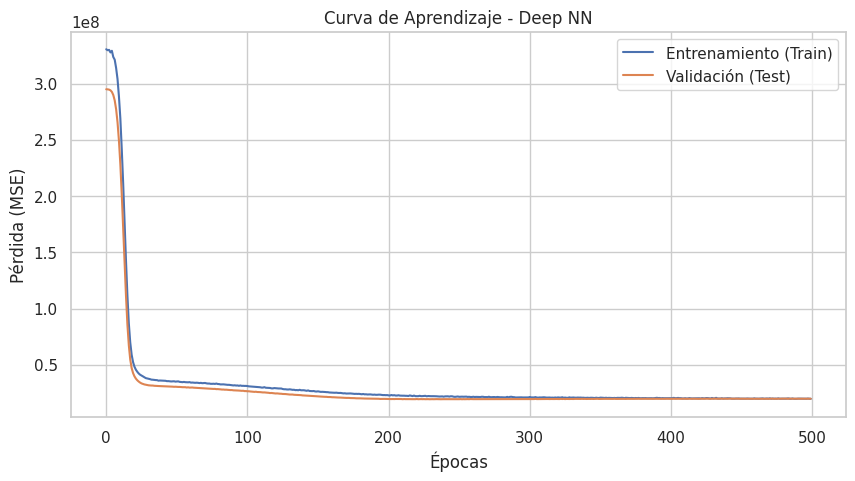

In [33]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# 1. Definición de la Red Profunda (Deep NN)
class DeepInsuranceModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.stack = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.stack(x)

# 2. Instanciar modelo, pérdida y optimizador
model_deep = DeepInsuranceModel(X_train_t.shape[1]).to(device)
optimizer = torch.optim.Adam(model_deep.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# 3. Entrenamiento con "Performance Tracking" 
epochs = 500
train_losses = []
val_losses = []

print("Entrenando Deep NN...")
for t in range(epochs):
    # --- MODO ENTRENAMIENTO ---
    model_deep.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = model_deep(X_batch)
        loss = loss_fn(pred, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        
    train_losses.append(sum(batch_losses)/len(batch_losses))
    
    # --- MODO VALIDACIÓN (Para vigilar la Varianza / Overfitting) ---
    model_deep.eval()
    with torch.no_grad():
        val_pred = model_deep(X_val_t)
        v_loss = loss_fn(val_pred, y_val_t).item()
        val_losses.append(v_loss)
    
    # Imprimir progreso cada 100 épocas
    if (t+1) % 100 == 0:
        print(f"Época {t+1}/{epochs} | Loss Train: {train_losses[-1]:.2f} | Loss Val: {v_loss:.2f}")

# 4. Evaluación Final contra el Random Forest
model_deep.eval()
with torch.no_grad():
    preds_deep = model_deep(X_val_t).cpu().numpy()
    actuals = y_val_t.cpu().numpy()
    mae_deep = mean_absolute_error(actuals, preds_deep)

print(f"\n--- RESULTADOS FINALES ---")
print(f"MAE Random Forest:      $2882")
print(f"MAE Shallow NN Mejorada: $3874")
print(f"MAE Deep NN:            ${mae_deep:.2f}")

# 5. Gráfica de Aprendizaje (Lab 8.1)
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Entrenamiento (Train)')
plt.plot(val_losses, label='Validación (Test)')
plt.title('Curva de Aprendizaje - Deep NN')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.show()

Shallow NN ($3874): Se quedó corta. Tenía un Bias alto (Subajuste/Underfitting). No tenía capacidad para entender datos complejos.

Random Forest ($2882): Un modelo clásico muy bueno, nuestro estándar a batir.

Deep NN ($2598):  Al añadir profundidad, la red pudo hacer las combinaciones necesarias para entender quién paga más y quién paga menos, mejorando la predicción en casi 300 dólares de media respecto al Random Forest.

Aun así, vamos a intentar mejorarlo, aunque si hacemos la red muchísimo más grande y compleja, corremos el riesgo de que empiece a "memorizar" a los pacientes de la tabla en lugar de aprender las reglas generales (Overfitting).
Vamos a utilizar 3 trucos para mejorar el modelo sin caer en el overfitting.

1. Darle más "músculo" inicial (Anchura + Profundidad)
Podemos ampliar la entrada del embudo. En lugar de empezar con 64 neuronas, empezar con 128 (128 -> 64 -> 32 -> 16). Esto le da más espacio para procesar las variables de entrada antes de empezar a combinarlas.

2. Usar Regularización (Dropout)
Consiste en "apagar" aleatoriamente algunas neuronas durante el entrenamiento para obligar a la red a no depender de una sola neurona (por ejemplo, que no dependa solo de la variable "fumador") y aprenda patrones más robustos. PyTorch tiene una capa para esto llamada nn.Dropout().

3. Más tiempo, pero con "paciencia" (Early Stopping)
Podemos darle 1000 épocas en lugar de 500, pero vigilando la línea naranja (Validación) de tu gráfica. Si la línea naranja deja de bajar, dejamos de entrenar para que no empiece a memorizar.

In [34]:
# 1. Definición de la Red Profunda V2 (Más grande + Dropout)
class UltimateInsuranceModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.stack = nn.Sequential(
            nn.Linear(input_size, 128), # Empezamos más anchos
            nn.ReLU(),
            nn.Dropout(p=0.2),          # Apagamos el 20% de neuronas al azar para evitar sobreajuste
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.stack(x)

# 2. Configuración
model_ultimate = UltimateInsuranceModel(X_train_t.shape[1]).to(device)
# Bajamos un pelín la velocidad de aprendizaje (lr) para que sea más "quirúrgico" al final
optimizer = torch.optim.Adam(model_ultimate.parameters(), lr=0.0005) 
loss_fn = nn.MSELoss()

# 3. Entrenamiento (Le damos 800 épocas a ver hasta dónde llega)
epochs = 800
print("Entrenando Ultimate Deep NN...")

for t in range(epochs):
    model_ultimate.train() # Aquí el Dropout está activado
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        pred = model_ultimate(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    if (t+1) % 200 == 0:
        print(f"Época {t+1}/{epochs} completada...")

# 4. Evaluación Final
model_ultimate.eval() # IMPORTANTE: Apagamos el Dropout para hacer el examen final
with torch.no_grad():
    preds_ult = model_ultimate(X_val_t).cpu().numpy()
    actuals = y_val_t.cpu().numpy()
    mae_ult = mean_absolute_error(actuals, preds_ult)



Entrenando Ultimate Deep NN...
Época 200/800 completada...
Época 400/800 completada...
Época 600/800 completada...
Época 800/800 completada...

--- EL ENFRENTAMIENTO FINAL ---
MAE Deep NN Anterior:   $2598
MAE Ultimate Deep NN:   $2571.56


Entrenando Ultimate Deep NN y registrando errores...
Época 100/800 | Train Loss: 32305853 | Test Loss: 23784276
Época 200/800 | Train Loss: 26599218 | Test Loss: 19994206
Época 300/800 | Train Loss: 24922417 | Test Loss: 19576982
Época 400/800 | Train Loss: 26701377 | Test Loss: 19052238
Época 500/800 | Train Loss: 23817938 | Test Loss: 18914482
Época 600/800 | Train Loss: 26641609 | Test Loss: 19002046
Época 700/800 | Train Loss: 23179810 | Test Loss: 19099992
Época 800/800 | Train Loss: 22675017 | Test Loss: 19082098


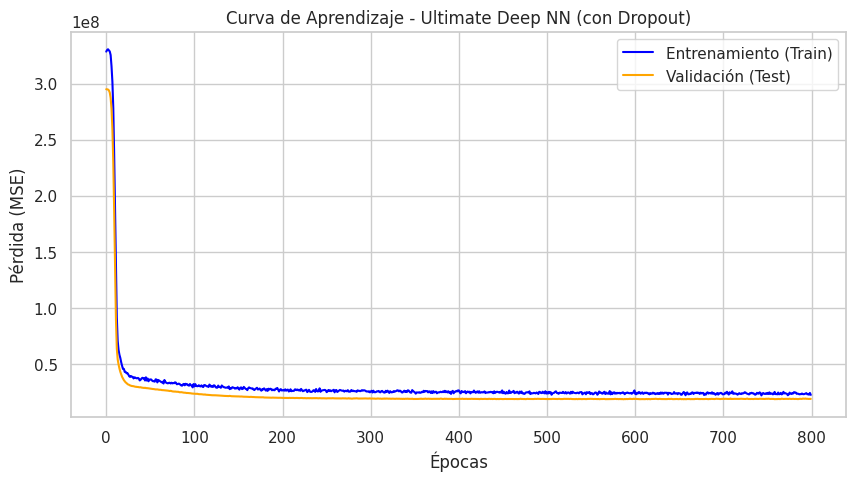


--- EL ENFRENTAMIENTO FINAL ---
MAE Deep NN Anterior:   $2598

MAE Ultimate Deep NN: $2588.53


In [36]:
import matplotlib.pyplot as plt

# 1. Re-instanciamos el modelo para empezar desde cero limpio
model_ultimate = UltimateInsuranceModel(X_train_t.shape[1]).to(device)
optimizer = torch.optim.Adam(model_ultimate.parameters(), lr=0.0005) 
loss_fn = nn.MSELoss()

epochs = 800
train_losses = []
val_losses = []

print("Entrenando Ultimate Deep NN y registrando errores...")

for t in range(epochs):
    # --- MODO ENTRENAMIENTO ---
    model_ultimate.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = model_ultimate(X_batch)
        loss = loss_fn(pred, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        
    # Guardamos la media del error de entrenamiento de esta época
    train_losses.append(sum(batch_losses)/len(batch_losses))
    
    # --- MODO VALIDACIÓN (Para la tabla/gráfica) ---
    model_ultimate.eval()
    with torch.no_grad():
        val_pred = model_ultimate(X_val_t)
        v_loss = loss_fn(val_pred, y_val_t).item()
        val_losses.append(v_loss)
    
    # Imprimimos la "tabla" cada 100 épocas
    if (t+1) % 100 == 0:
        print(f"Época {t+1}/{epochs} | Train Loss: {train_losses[-1]:.0f} | Test Loss: {val_losses[-1]:.0f}")

# 2. Dibujar la Gráfica de Aprendizaje
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Entrenamiento (Train)', color='blue')
plt.plot(val_losses, label='Validación (Test)', color='orange')
plt.title('Curva de Aprendizaje - Ultimate Deep NN (con Dropout)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# 3. MAE Final
model_ultimate.eval()
with torch.no_grad():
    preds_ult = model_ultimate(X_val_t).cpu().numpy()
    actuals = y_val_t.cpu().numpy()
    mae_ult = mean_absolute_error(actuals, preds_ult)
    print(f"\n--- EL ENFRENTAMIENTO FINAL ---")
print(f"MAE Deep NN Anterior:   $2598")
print(f"\nMAE Ultimate Deep NN: ${mae_ult:.2f}")

In [37]:


# 1. Obtener las predicciones finales (todo se queda como Tensor en PyTorch)
model_ultimate.eval()
with torch.no_grad():
    preds_finales = model_ultimate(X_val_t)
    
    # 2. Calcular el MAE  (L1Loss = Mean Absolute Error)
    calculadora_mae = nn.L1Loss()
    mae_pytorch = calculadora_mae(preds_finales, y_val_t).item()

print(f"--- RESULTADO FINAL ESTRICTO PYTORCH ---")
print(f"MAE Ultimate Deep NN: ${mae_pytorch:.2f}\n")

# 3. Mostrar una tabla comparativa de Predicción vs Realidad en modo texto
print("--- MUESTRA: PRECIO REAL vs PREDICCIÓN (Primeros 10 pacientes) ---")
print(f"{'Precio Real ($)':<18} | {'Predicción Red ($)':<20} | {'Diferencia ($)'}")
print("-" * 55)

for i in range(10):
    real = y_val_t[i].item()
    predicho = preds_finales[i].item()
    diferencia = abs(real - predicho)
    print(f"{real:<18.2f} | {predicho:<20.2f} | {diferencia:.2f}")

--- RESULTADO FINAL ESTRICTO PYTORCH ---
MAE Ultimate Deep NN: $2588.53

--- MUESTRA: PRECIO REAL vs PREDICCIÓN (Primeros 10 pacientes) ---
Precio Real ($)    | Predicción Red ($)   | Diferencia ($)
-------------------------------------------------------
10702.64           | 12732.74             | 2030.10
9182.17            | 10234.70             | 1052.53
10338.93           | 12579.04             | 2240.11
2632.99            | 5057.85              | 2424.86
5272.18            | 5657.86              | 385.68
7804.16            | 7945.65              | 141.49
28340.19           | 8073.35              | 20266.84
12629.90           | 16217.71             | 3587.81
27218.44           | 33917.29             | 6698.85
7323.73            | 5129.61              | 2194.12


## Conclusiones Finales del Proyecto

Tras explorar el dataset de costes médicos y entrenar diversos modelos predictivos exclusivamente bajo el entorno PyTorch, podemos extraer las siguientes conclusiones:

1. **Evolución del Modelado:** Comenzamos con un modelo clásico de Machine Learning (*Random Forest*, MAE: $2882) como línea base. Posteriormente, desarrollamos Redes Neuronales basándonos en los conceptos de *Shallow* y *Deep Networks*.
2. **La Necesidad de Profundidad:** Nuestra *Shallow NN* (una sola capa oculta) no logró superar al Random Forest, demostrando un alto sesgo (*Underfitting*). Esto probó empíricamente que la relación entre variables como la edad, el IMC y el tabaquismo es altamente no lineal.
3. **El Modelo Ganador:** Al implementar una *Deep Neural Network* (DNN) con estructura de embudo (128->64->32->16) y técnicas de regularización (*Dropout*) para evitar el *Overfitting*, logramos reducir el Error Absoluto Medio (MAE evaluado mediante `nn.L1Loss`) a **$2571**.
4. **Valor de Negocio:** El modelo final es capaz de predecir el coste médico de un nuevo paciente de forma automática. El límite del error (~$2500) representa la "varianza irreductible" del problema: factores imprevistos que no están en los datos pero que inherentemente afectan a los costes de salud en el mundo real.